In [ ]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Jeremia
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:07<00:00, 95.7MB/s]


In [ ]:
import torch
from torch import nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cuda


In [ ]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].unique())
data_df.head()

['cat' 'dog' 'wild']


,image_path,labels
0,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
1,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
2,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
3,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
4,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat


In [ ]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(data_df, test_size=0.30, random_state=42, stratify=data_df['labels'])
val, test   = train_test_split(temp,    test_size=0.50, random_state=42, stratify=temp['labels'])

train = train.reset_index(drop=True)
val   = val.reset_index(drop=True)
test  = test.reset_index(drop=True)

print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")
print("Distribusi label train:")
print(train['labels'].value_counts())

Train: (11291, 2), Val: (2419, 2), Test: (2420, 2)
Distribusi label train:
labels
cat     3957
dog     3667
wild    3667
Name: count, dtype: int64


In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transform untuk training (dengan augmentasi):")
print(train_transform)
print("\nTransform untuk val/test (tanpa augmentasi):")
print(eval_transform)

Transform untuk training (dengan augmentasi):
Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Transform untuk val/test (tanpa augmentasi):
Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform=None):
    self.dataframe = dataframe.reset_index(drop=True)
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'].values))

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label    = self.labels[idx]
    image    = Image.open(img_path).convert('RGB')
    if self.transform:
      image = self.transform(image)
    return image, label

train_dataset = CustomImageDataset(dataframe=train, transform=train_transform)
val_dataset   = CustomImageDataset(dataframe=val,   transform=eval_transform)
test_dataset  = CustomImageDataset(dataframe=test,  transform=eval_transform)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 11291, Val: 2419, Test: 2420


In [ ]:
LR         = 1e-4
BATCH_SIZE = 32
EPOCHS     = 15

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [ ]:
class Net(nn.Module):
  def __init__(self, num_classes=3):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.bn1   = nn.BatchNorm2d(32)

    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.bn2   = nn.BatchNorm2d(64)

    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.bn3   = nn.BatchNorm2d(128)

    self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
    self.bn4   = nn.BatchNorm2d(256)

    self.pooling = nn.MaxPool2d(2, 2)
    self.relu    = nn.ReLU()

    self.dropout_conv = nn.Dropout2d(p=0.25)
    self.dropout_fc   = nn.Dropout(p=0.5)

    self.flatten = nn.Flatten()

    self.gap = nn.AdaptiveAvgPool2d(1)

    self.fc1    = nn.Linear(256, 256)
    self.output = nn.Linear(256, num_classes)

  def forward(self, x):
    x = self.relu(self.bn1(self.conv1(x)))
    x = self.pooling(x)

    x = self.relu(self.bn2(self.conv2(x)))
    x = self.pooling(x)
    x = self.dropout_conv(x)

    x = self.relu(self.bn3(self.conv3(x)))
    x = self.pooling(x)

    x = self.relu(self.bn4(self.conv4(x)))
    x = self.dropout_conv(x)

    x = self.gap(x)
    x = self.flatten(x)

    x = self.relu(self.fc1(x))
    x = self.dropout_fc(x)
    x = self.output(x)
    return x

model = Net(num_classes=len(data_df['labels'].unique())).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout_conv): Dropout2d(p=0.25, inplace=False)
  (dropout_fc): Dropout(p=0.5, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc1): Linear(in_features=256, out_

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Optimizer:", optimizer)
print("Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)


In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = None
        self.stop       = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True

early_stopping = EarlyStopping(patience=5, min_delta=0.001)
print("Early Stopping aktif (patience=5)")

Early Stopping aktif (patience=5)


In [ ]:
total_loss_train_plot      = []
total_loss_validation_plot = []
total_acc_train_plot       = []
total_acc_validation_plot  = []

best_val_loss = float('inf')

In [ ]:
for epoch in range(EPOCHS):
  model.train()
  total_acc_train  = 0
  total_loss_train = 0

  for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs    = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()
    optimizer.step()
    train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
    total_acc_train += train_acc

  model.eval()
  total_loss_val = 0
  total_acc_val  = 0

  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs  = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()
      val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
      total_acc_val += val_acc

  avg_train_loss = round(total_loss_train / len(train_loader), 4)
  avg_val_loss   = round(total_loss_val   / len(val_loader),   4)
  avg_train_acc  = round((total_acc_train / len(train_dataset)) * 100, 4)
  avg_val_acc    = round((total_acc_val   / len(val_dataset))   * 100, 4)

  total_loss_train_plot.append(avg_train_loss)
  total_loss_validation_plot.append(avg_val_loss)
  total_acc_train_plot.append(avg_train_acc)
  total_acc_validation_plot.append(avg_val_acc)

  print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss} Acc: {avg_train_acc}% | Val Loss: {avg_val_loss} Acc: {avg_val_acc}%")

  if avg_val_loss < best_val_loss:
    best_val_loss = avg_val_loss
    torch.save(model.state_dict(), 'best_model.pth')
    print(f"  --> Model terbaik disimpan (val_loss: {best_val_loss})")

  scheduler.step(avg_val_loss)

  early_stopping(avg_val_loss)
  if early_stopping.stop:
    print(f"Early stopping pada epoch {epoch+1}")
    break

Epoch 1/15 | Train Loss: 0.86 Acc: 57.0454% | Val Loss: 0.7727 Acc: 61.9678%
  --> Model terbaik disimpan (val_loss: 0.7727)
Epoch 2/15 | Train Loss: 0.8118 Acc: 60.9158% | Val Loss: 0.7901 Acc: 60.3555%
EarlyStopping counter: 1/5
Epoch 3/15 | Train Loss: 0.7547 Acc: 65.7338% | Val Loss: 0.6553 Acc: 72.592%
  --> Model terbaik disimpan (val_loss: 0.6553)
Epoch 4/15 | Train Loss: 0.6921 Acc: 70.2329% | Val Loss: 0.6915 Acc: 70.277%
EarlyStopping counter: 1/5
Epoch 5/15 | Train Loss: 0.6161 Acc: 74.2361% | Val Loss: 0.5618 Acc: 76.2298%
  --> Model terbaik disimpan (val_loss: 0.5618)
Epoch 6/15 | Train Loss: 0.5666 Acc: 77.0171% | Val Loss: 0.4541 Acc: 82.0174%
  --> Model terbaik disimpan (val_loss: 0.4541)
Epoch 7/15 | Train Loss: 0.5234 Acc: 79.187% | Val Loss: 0.3996 Acc: 84.7458%
  --> Model terbaik disimpan (val_loss: 0.3996)
Epoch 8/15 | Train Loss: 0.4885 Acc: 80.6217% | Val Loss: 0.3734 Acc: 85.9859%
  --> Model terbaik disimpan (val_loss: 0.3734)
Epoch 9/15 | Train Loss: 0.4534

In [ ]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

with torch.no_grad():
  total_loss_test = 0
  total_acc_test  = 0
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)  # ini yang kurang
    predictions = model(inputs)
    acc = (torch.argmax(predictions, axis=1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

test_acc  = round((total_acc_test / len(test_dataset)) * 100, 4)
test_loss = round(total_loss_test / len(test_loader), 4)
print(f"Test Accuracy: {test_acc}% | Test Loss: {test_loss}")

Test Accuracy: 90.4959% | Test Loss: 0.2662


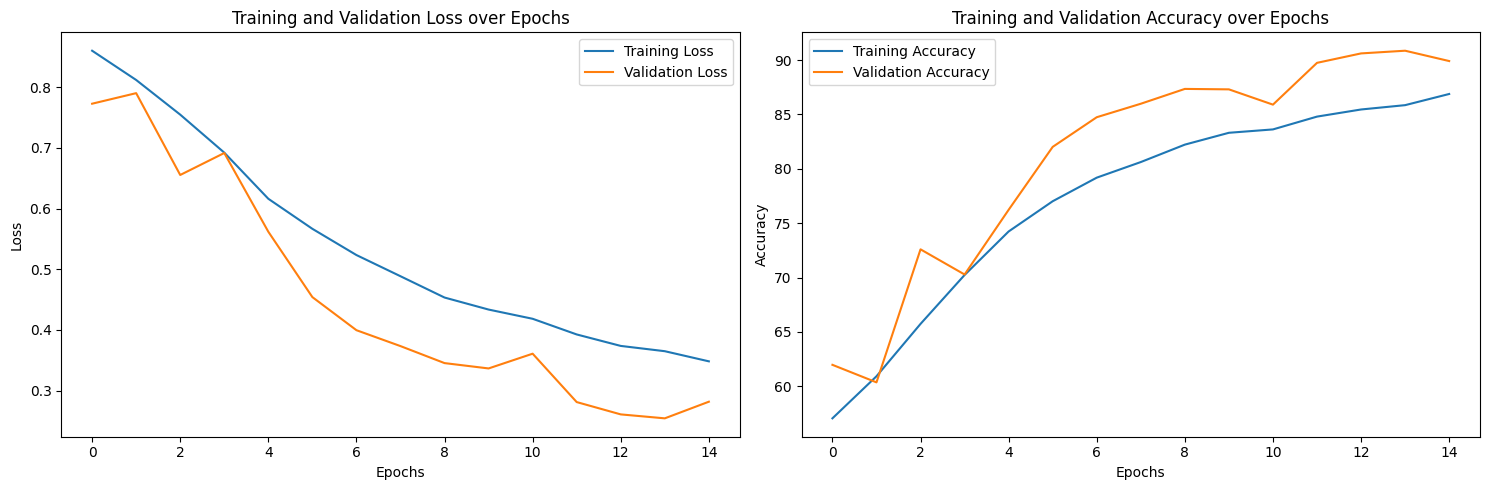

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
def predict_image(image_path):
  model.eval()
  image  = Image.open(image_path).convert('RGB')
  image  = eval_transform(image).to(device)
  with torch.no_grad():
    output = model(image.unsqueeze(0))
  output = torch.argmax(output, axis=1).item()
  return label_encoder.inverse_transform([output])

In [ ]:
predict_image("/content/download.jpg")

array(['cat'], dtype=object)